# **WIA 1006 Machine Learning Group Assignment**

**Group members:**

1. Kwek Chee Ling 23080328
2. Teoh En Xi 24004582
3. Mah Kah Mun 24004590
4. Gianina Lazaroo 24066775
5. Lee Shian Peng 23104094

**Semester Session:**



*   Sem 2 2024/2025



**Theme:**


*   Crop Production by District




**Lecturer Name:**


* Dr. Saw Shier Nee


* Dr. Muhammad Shahreeza Safiruz bin Kassim










**Our Project**

Our group chose to explore the Crop Production by District dataset for this project. The main objective is to predict whether crop production in a district is high or low based on various agricultural features. By applying different machine learning classification algorithms, we aim to build a model that accurately categorizes production levels. This analysis can provide valuable insights for decision-makers in agriculture, helping to support effective planning and resource allocation.

# Insert Data and Libraries

Mount at google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install required packages

In [ ]:
!pip install -q catboost lightgbm imbalanced-learn
!pip install lightgbm catboost

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

Import dataset

In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/crops_district_production.csv")
df2 = pd.read_csv("/content/drive/MyDrive/crops_state.csv")
df = pd.concat([df1, df2], ignore_index=True)

# Initial Data Exploration

In [ ]:
df.head()

,date,state,district,crop_type,crop_species,production,planted_area
0,2017-01-01,Johor,Batu Pahat,cash_crops,cassava,920.5,NaN
1,2017-01-01,Johor,Batu Pahat,cash_crops,groundnuts,0.0,NaN
2,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_corn,0.0,NaN
3,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_potato,350.0,NaN
4,2017-01-01,Johor,Batu Pahat,cash_crops,yam,395.4,NaN


In [ ]:
df.tail()

,date,state,district,crop_type,crop_species,production,planted_area
11861,2018-01-01,W.P. Labuan,NaN,vegetables,NaN,333.4,72.5
11862,2019-01-01,W.P. Labuan,NaN,vegetables,NaN,334.0,57.1
11863,2020-01-01,W.P. Labuan,NaN,vegetables,NaN,358.9,26.9
11864,2021-01-01,W.P. Labuan,NaN,vegetables,NaN,462.2,65.1
11865,2022-01-01,W.P. Labuan,NaN,vegetables,NaN,340.8,73.4


Here are the description of each columns name:

1. Date: the date when the data was recorded (planting or harvesting date)

2. State: the name of the state or origin where the crop data was collected.

3. District: the specific district within the state where the data was recorded.

4. Crop Type: the genetal category of the crop

5. Crop species: the specific species or name of the crop

6. Production: the amount of crop produced, typically measured in metric tons or kilograms

7. Planted area: the area of land used to plant the crop, usually measured in hectares or acres.

Determine the datatype of Each Column

In [ ]:
print (df.dtypes)

date             object
state            object
district         object
crop_type        object
crop_species     object
production      float64
planted_area    float64
dtype: object


In [ ]:
print("Initial shape:", df.shape)
df.info()

Initial shape: (11866, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11866 entries, 0 to 11865
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          11866 non-null  object 
 1   state         11866 non-null  object 
 2   district      11002 non-null  object 
 3   crop_type     11866 non-null  object 
 4   crop_species  11002 non-null  object 
 5   production    11866 non-null  float64
 6   planted_area  864 non-null    float64
dtypes: float64(2), object(5)
memory usage: 649.1+ KB


take an overview about the summary statistic of each numerical features

In [ ]:
df.describe()

,production,planted_area
count,1.186600e+04,864.000000
mean,4.556215e+05,16402.323495
std,1.166744e+07,62523.782112
min,0.000000e+00,0.000000
25%,0.000000e+00,91.350000
50%,9.298150e-01,1296.900000
75%,8.250000e+01,7658.350000
max,5.280962e+08,699980.000000


# Data Preprocessing

Check for duplicates




In [ ]:
duplicates = df[df.duplicated()]
print(duplicates)

print("Number of duplicate rows: ", df.duplicated().sum())

            date    state  district         crop_type  crop_species  \
857   2017-01-01    Johor   Tangkak  industrial_crops     areca_nut   
861   2017-01-01    Johor   Tangkak  industrial_crops        coffee   
863   2017-01-01    Johor   Tangkak  industrial_crops     honey_bee   
865   2017-01-01    Johor   Tangkak  industrial_crops   kelulut_bee   
869   2017-01-01    Johor   Tangkak  industrial_crops       roselle   
...          ...      ...       ...               ...           ...   
9445  2017-01-01  Sarawak  Sri Aman             fruit  dragon_fruit   
9461  2017-01-01  Sarawak  Sri Aman             fruit        papaya   
9469  2017-01-01  Sarawak  Sri Aman             fruit     starfruit   
9478  2017-01-01  Sarawak  Sri Aman  industrial_crops        coffee   
9480  2017-01-01  Sarawak  Sri Aman  industrial_crops          sago   

      production  planted_area  
857          0.0           NaN  
861          0.0           NaN  
863          0.0           NaN  
865          0.

Drop duplicates

In [ ]:
df = df.drop_duplicates()

There are a total of 117 duplicated rows and was dropped.

Remove 'Malaysia' row if present in state column

In [ ]:
df = df[df["state"] != "Malaysia"]
print(df["state"].unique())  # Show all unique values in the state column

['Johor' 'Kedah' 'Kelantan' 'Melaka' 'Negeri Sembilan' 'Pahang' 'Perak'
 'Perlis' 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu'
 'W.P. Labuan' 'W.P. Kuala Lumpur']


Create target variable: high (1) or low (0) production

production_level
0    5848
1    5847
Name: count, dtype: int64


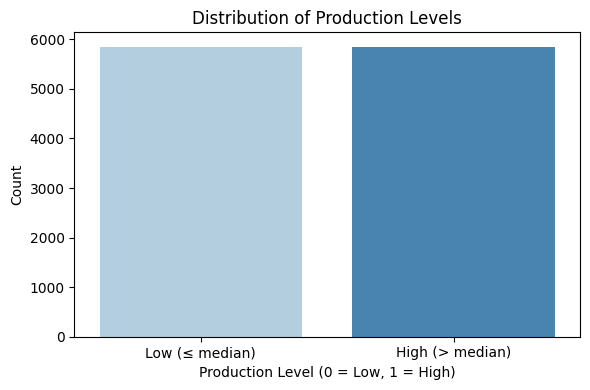

In [ ]:
# Convert production into binary class based on median
median_production = df['production'].median()
df['production_level'] = df['production'].apply(lambda x: 1 if x > median_production else 0)

# Check the distribution
print(df['production_level'].value_counts())

# Visualize the distribution as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='production_level', palette='Blues')
plt.title('Distribution of Production Levels')
plt.xlabel('Production Level (0 = Low, 1 = High)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Low (≤ median)', 'High (> median)'])
plt.tight_layout()
plt.show()

The distribution of the production_level variable is nearly perfectly balanced, with 5,848 instances classified as Low (≤ median) and 5,847 as High (> median). This balance is ideal for binary classification tasks, as it helps prevent model bias toward either class and supports more reliable and fair performance across both categories.

Check for missing value

        Feature  Missing Count  Missing %
6  planted_area          10885  93.073963
2      district            810   6.926037
4  crop_species            810   6.926037


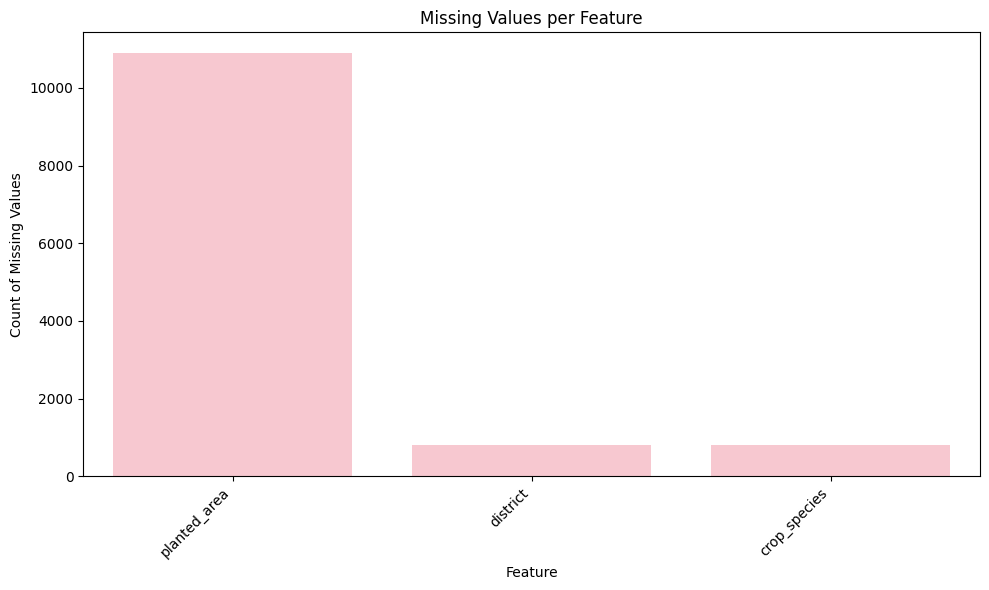

In [ ]:
# Check missing values
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing %': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(missing_df)

# Bar chart to visualize missing values
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df, x='Feature', y='Missing Count', color='pink')
plt.xticks(rotation=45, ha='right')
plt.title('Missing Values per Feature')
plt.xlabel('Feature')
plt.ylabel('Count of Missing Values')
plt.tight_layout()
plt.show()

There are some missing value in the dataset due to combination of 2 different dataset. However, we decided to keep those data as they might be significant for model training.

Detect outlier

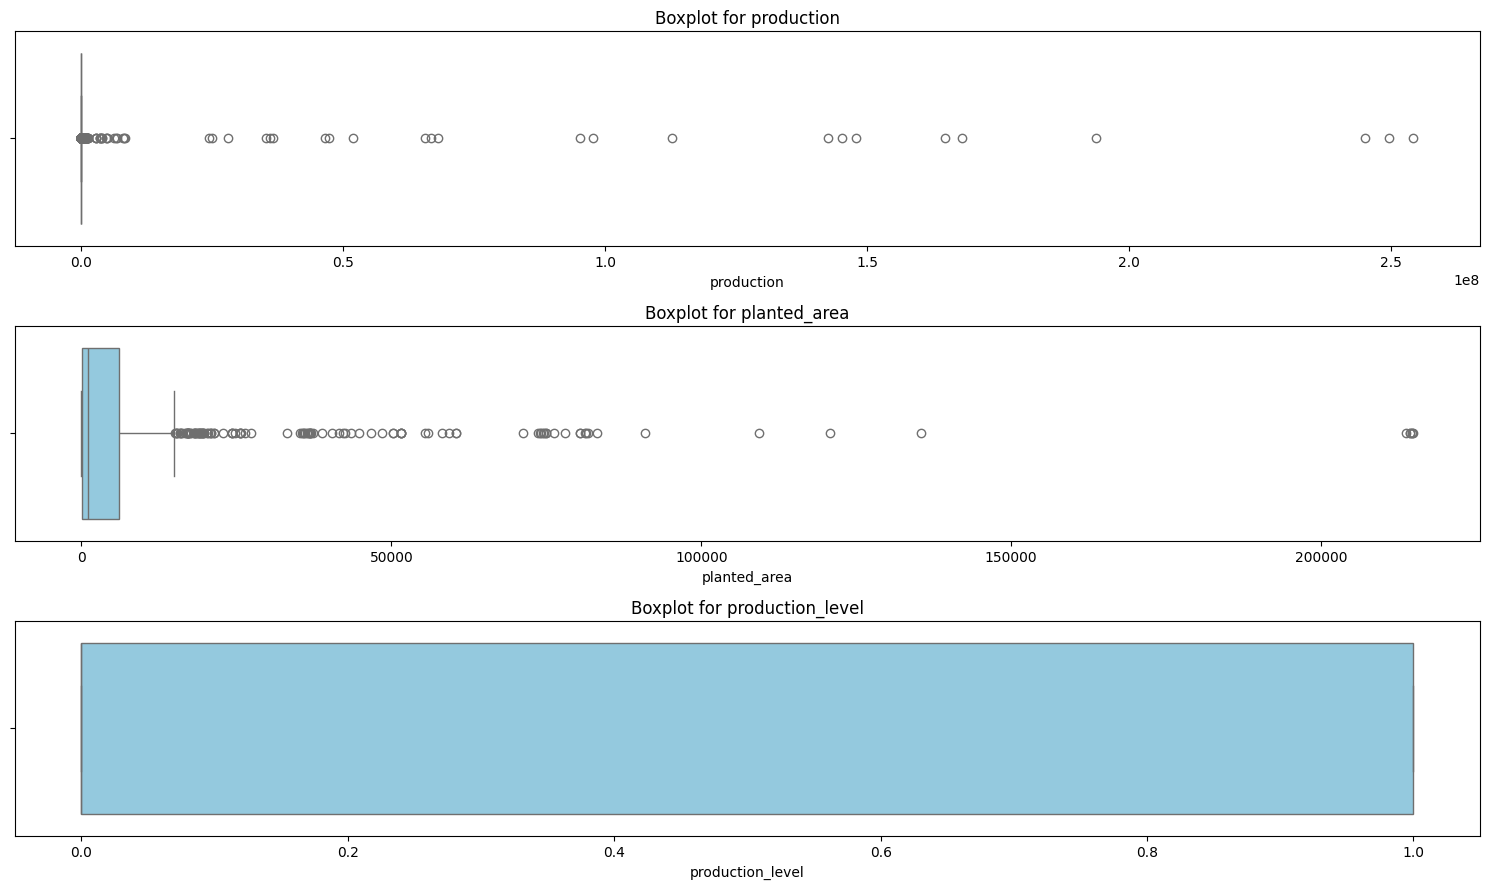

Outlier counts per feature:
{'production': 2153, 'planted_area': 115, 'production_level': 0}


In [ ]:
# Boxplot for visualizing outliers
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, len(numerical_cols) * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i + 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

# Outlier detection using IQR method (flagging only)
outlier_flags = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_flags[col] = len(outliers)

print("Outlier counts per feature:")
print(outlier_flags)

There are outliers occur in column 'production' and 'planted_area' but those data are kept as it is significant to determine low or high production.

Impute numberical columns

In [ ]:
df['planted_area_missing'] = df['planted_area'].isnull().astype(int)
df['production_missing'] = df['production'].isnull().astype(int)

Use IterativeImputer from Scikit-learn to fill in missing values

In [ ]:
num_cols = ['planted_area', 'production']
imp = IterativeImputer(random_state=42)
df[num_cols] = imp.fit_transform(df[num_cols])

Extract year, month, day from 'date'

In [ ]:
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month
df['day'] = pd.to_datetime(df['date']).dt.day

Drop unwanted columns

In [ ]:
df.drop(columns=['planted_area', 'date'], inplace=True)

# Feature Encoding and Scaling

Define features and target

In [ ]:
X = df.drop(columns=['production', 'production_level'])
y = df['production_level']

One-hot encode categorical variables

In [ ]:
X = pd.get_dummies(X, columns=['state', 'district', 'crop_type', 'crop_species'], drop_first=True)

Impute any remaining missing values

In [ ]:
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

Split into train-test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

Standardization

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature Extraction using PCA

In [ ]:
def apply_pca(X_train, X_test, n_components=30):
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    print(f"PCA explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")
    return X_train_pca, X_test_pca, pca

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

def plot_feature_importance(model, feature_names, model_name, top_n=20):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):  # CatBoost
        importances = model.get_feature_importance()
    else:
        print(f"Model {model_name} does not support feature importance.")
        return

    feat_imp = pd.Series(importances, index=feature_names)
    feat_imp = feat_imp.sort_values(ascending=False)[:top_n]

    plt.figure(figsize=(8,5))
    sns.barplot(x=feat_imp.values, y=feat_imp.index)
    plt.title(f'Top {top_n} Feature Importances - {model_name}')
    plt.show()

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original features into a smaller set of uncorrelated components while retaining most of the data's variance. By applying PCA, we reduce feature redundancy and noise, improve computational efficiency, and potentially enhance model performance by focusing on the most informative aspects of the dataset.

#Model Selection, Training and Evaluation

Given that our target variable is production_level, which is a binary variable indicating high or low crop production, we have chosen the following 6 algorithms for classification:



*   Random Forest Classifier
*   Histogram-based Gradient Boosting Classifier
*   Logistic Regression
*   XGBoost Classifier
*   LightGBM Classifier
*   CatBoost Classifier











Training and evaluating: Random Forest
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1170
           1       0.81      0.79      0.80      1169

    accuracy                           0.80      2339
   macro avg       0.80      0.80      0.80      2339
weighted avg       0.80      0.80      0.80      2339

[[953 217]
 [241 928]]
--------------------------------------------------

Training and evaluating: HistGradient Boosting
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1170
           1       0.81      0.79      0.80      1169

    accuracy                           0.80      2339
   macro avg       0.80      0.80      0.80      2339
weighted avg       0.80      0.80      0.80      2339

[[950 220]
 [251 918]]
--------------------------------------------------

Training and evaluating: Logistic Regression
              precision    recall  f1-score   support

         

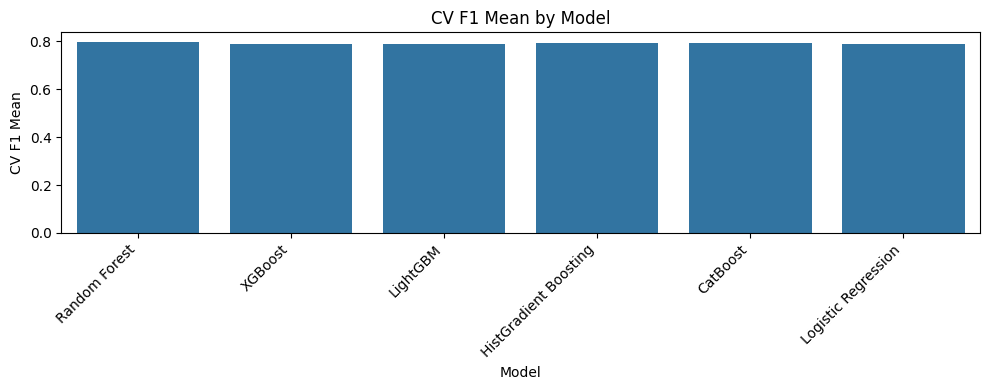

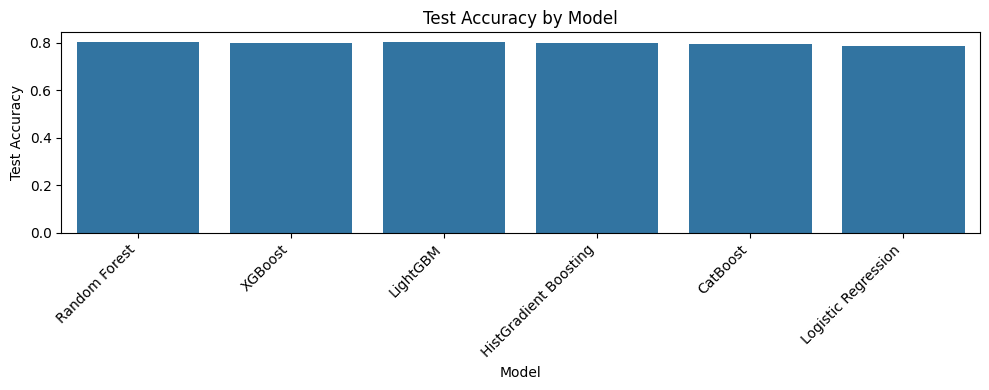

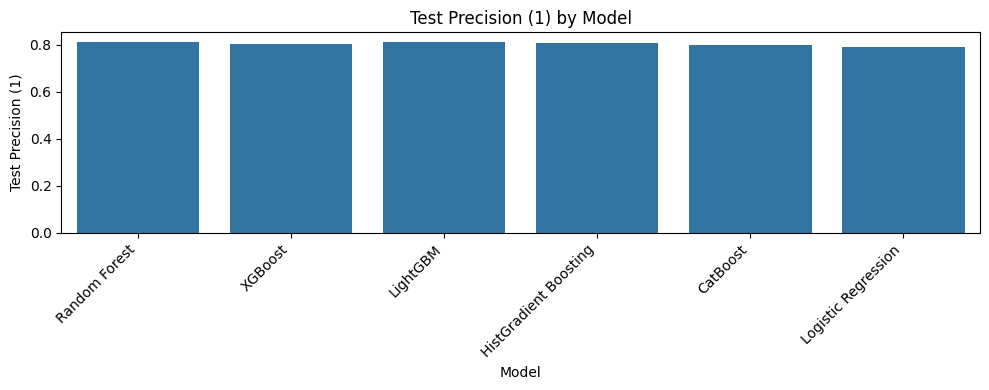

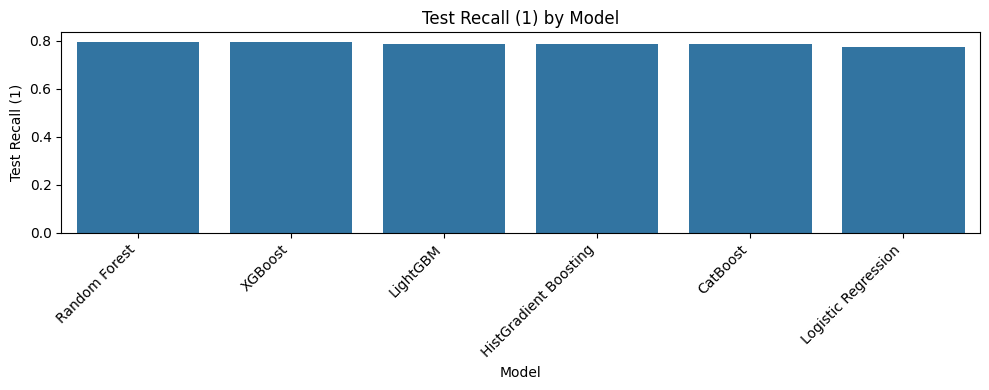

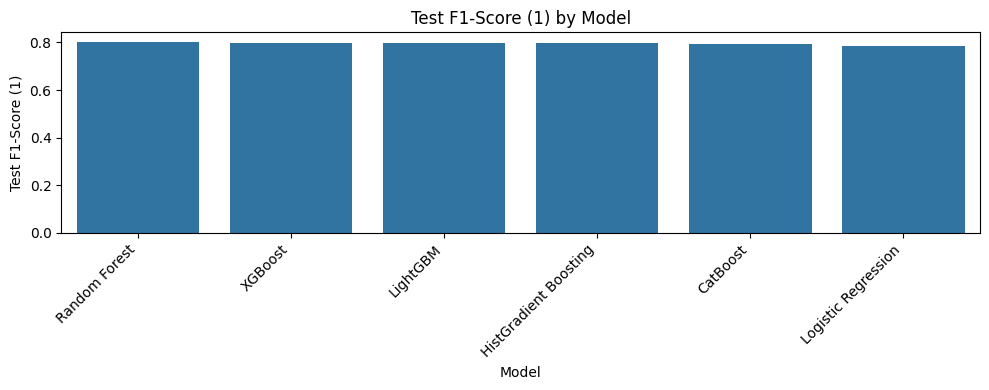

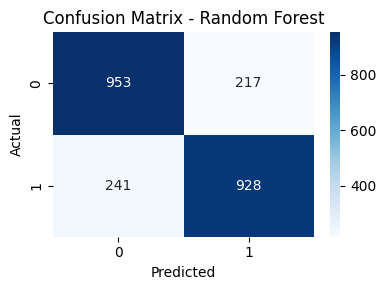

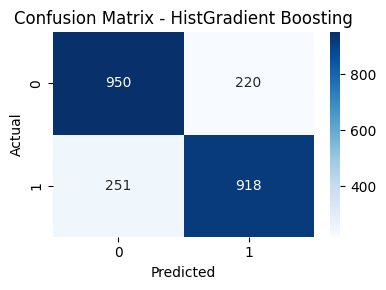

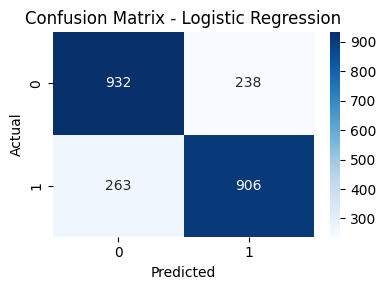

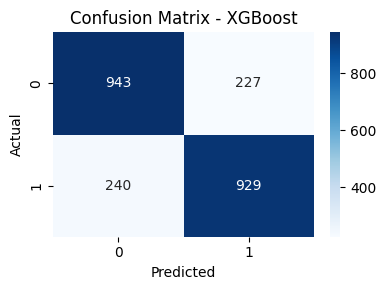

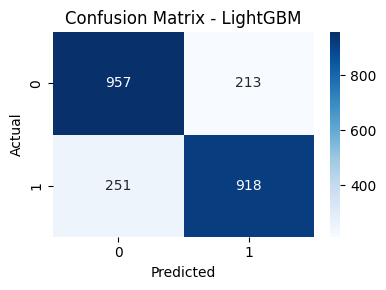

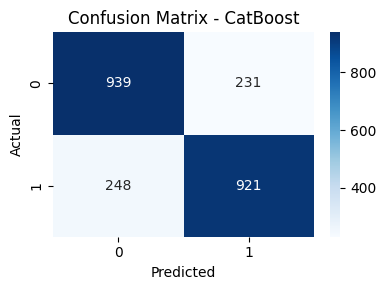


=== Summary Table ===
                   Model  CV F1 Mean  Test Accuracy  Test Precision (1)  \
0          Random Forest    0.797786       0.804190            0.810480   
1                XGBoost    0.790777       0.800342            0.803633   
2               LightGBM    0.789689       0.801625            0.811671   
3  HistGradient Boosting    0.791077       0.798632            0.806678   
4               CatBoost    0.795177       0.795212            0.799479   
5    Logistic Regression    0.790826       0.785806            0.791958   

   Test Recall (1)  Test F1-Score (1)  
0         0.793841           0.802074  
1         0.794696           0.799140  
2         0.785287           0.798261  
3         0.785287           0.795839  
4         0.787853           0.793623  
5         0.775021           0.783398  


In [ ]:
import warnings
warnings.filterwarnings("ignore")


models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'HistGradient Boosting': HistGradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

# Cross-validation and Evaluation
results = []
conf_matrices = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTraining and evaluating: {name}")

    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = conf_matrix

    results.append({
        'Model': name,
        'CV F1 Mean': scores.mean(),
        'Test Accuracy': report['accuracy'],
        'Test Precision (1)': report['1']['precision'],
        'Test Recall (1)': report['1']['recall'],
        'Test F1-Score (1)': report['1']['f1-score'],
    })

    print(classification_report(y_test, y_pred))
    print(conf_matrix)
    print("-" * 50)

# Results DataFrame
results_df = pd.DataFrame(results).sort_values(by='Test F1-Score (1)', ascending=False)

# Plot Metrics
metrics_to_plot = ['CV F1 Mean', 'Test Accuracy', 'Test Precision (1)', 'Test Recall (1)', 'Test F1-Score (1)']
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=results_df, x='Model', y=metric)
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Confusion Matrices
for model_name, matrix in conf_matrices.items():
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Summary Table
print("\n=== Summary Table ===")
print(results_df.reset_index(drop=True))

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter grids for all models
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'HistGradient Boosting': {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'l2_regularization': [0.0, 0.1, 0.5]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 100],
        'max_depth': [-1, 10, 20]
    },
    'CatBoost': {
        'iterations': [100, 200, 300],
        'depth': [4, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5]
    }
}

# Dictionary to store best tuned models
best_models = {}
tuned_results = []

# Perform tuning for each model
for name, model in models.items():
    print(f"\n🔧 Tuning hyperparameters for: {name}")
    param_dist = param_grids[name]

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20,
        scoring='f1',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train_scaled, y_train)
    best_model = search.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    tuned_results.append({
        'Model': name,
        'Best Params': search.best_params_,
        'Test Accuracy': report['accuracy'],
        'Test Precision (1)': report['1']['precision'],
        'Test Recall (1)': report['1']['recall'],
        'Test F1-Score (1)': report['1']['f1-score']
    })

    print("Best Parameters:", search.best_params_)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", conf_matrix)
    print("-" * 60)

# Results DataFrame of Tuned Models
tuned_results_df = pd.DataFrame(tuned_results).sort_values(by='Test F1-Score (1)', ascending=False)

# Display summary
print("\n=== Tuned Model Summary ===")
print(tuned_results_df.reset_index(drop=True))



🔧 Tuning hyperparameters for: Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.81      1170
           1       0.81      0.79      0.80      1169

    accuracy                           0.80      2339
   macro avg       0.80      0.80      0.80      2339
weighted avg       0.80      0.80      0.80      2339

Confusion Matrix:
 [[953 217]
 [243 926]]
------------------------------------------------------------

🔧 Tuning hyperparameters for: HistGradient Boosting
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'max_iter': 200, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0.5}
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82     

Before hyperparameter tuning, the Random Forest model showed the best overall performance with a test F1-score of 0.802, while LightGBM achieved the highest test accuracy (0.8016) and precision (0.8117), making both strong contenders. After tuning, LightGBM emerged as the top performer with improved metrics across the board, achieving a test F1-score of 0.8167, accuracy of 0.8196, and precision of 0.8297. This indicates that hyperparameter tuning significantly enhanced model performance, particularly for LightGBM and XGBoost, both of which showed notable gains in predictive power and balance between precision and recall.

# Model Performance Summary

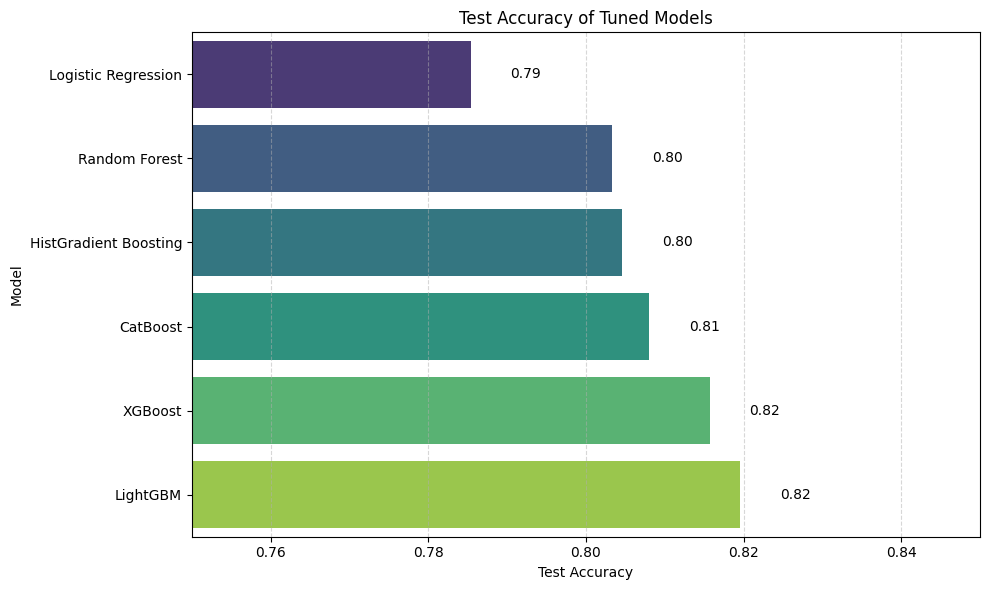


=== Tuned Model Performance Summary ===
                   Model                                        Best Params  \
0               LightGBM  {'num_leaves': 50, 'n_estimators': 300, 'max_d...   
1                XGBoost  {'subsample': 0.8, 'n_estimators': 300, 'max_d...   
2               CatBoost  {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iter...   
3  HistGradient Boosting  {'max_iter': 200, 'max_depth': None, 'learning...   
4          Random Forest  {'n_estimators': 200, 'min_samples_split': 5, ...   
5    Logistic Regression      {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}   

   Test Accuracy  Test Precision (1)  Test Recall (1)  Test F1-Score (1)  
0       0.819581            0.829656         0.804106           0.816681  
1       0.815733            0.819757         0.809239           0.814464  
2       0.808038            0.812500         0.800684           0.806549  
3       0.804617            0.814488         0.788708           0.801391  
4       0.803335            0.

In [ ]:
# Sort by Test Accuracy for better display
tuned_results_df_sorted = tuned_results_df.sort_values(by='Test Accuracy', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tuned_results_df_sorted,
    x='Test Accuracy',
    y='Model',
    palette='viridis'
)

# Add value labels
for i, value in enumerate(tuned_results_df_sorted['Test Accuracy']):
    plt.text(value + 0.005, i, f'{value:.2f}', va='center')

plt.title('Test Accuracy of Tuned Models')
plt.xlabel('Test Accuracy')
plt.ylabel('Model')
plt.xlim(0.75, 0.85)  # Adjust based on your accuracy range
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display the full summary table
print("\n=== Tuned Model Performance Summary ===")
print(tuned_results_df.reset_index(drop=True))


The performance comparison of six machine learning models shows that LightGBM and XGBoost are the top performers, both achieving the highest test accuracy of 0.82, followed closely by CatBoost at 0.81. HistGradient Boosting and Random Forest reach an accuracy of 0.80, while Logistic Regression trails with 0.79. While Logistic Regression is still competitive in precision and F1-Score, the ensemble models, particularly LightGBM and XGBoost, consistently outperform the others, making them the preferred choices for this task.

In conclusion, **LightGBM** emerges as the top model, with the highest test accuracy (0.82) and strong overall performance across precision, recall, and F1-Score. Its ability to handle large datasets and provide fast training time makes it a solid choice for this task.